In [14]:
pip install opencv-python


  Using cached opencv_python-4.12.0.88-cp37-abi3-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.2.6-cp312-cp312-win_amd64.whl.metadata (60 kB)
Using cached opencv_python-4.12.0.88-cp37-abi3-win_amd64.whl (39.0 MB)
Using cached numpy-2.2.6-cp312-cp312-win_amd64.whl (12.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.2.6 which is incompatible.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.2.6 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.6 which is incompatible.


In [25]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import os
import cv2

In [6]:
img = image.load_img(r"C:\Users\aka90\Desktop\abhi vs code\Deep_learning\traning\happy\download (2).jpeg")

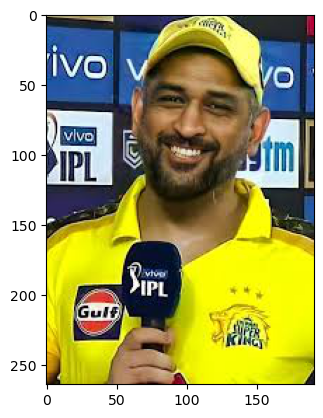

In [7]:
plt.imshow(img)

In [16]:
i1 = cv2.imread(r"C:\Users\aka90\Desktop\abhi vs code\Deep_learning\traning\happy\download (2).jpeg")
i1

array([[[133, 182, 184],
        [132, 181, 183],
        [129, 180, 183],
        ...,
        [ 71,  31, 167],
        [ 61,  14, 170],
        [ 47,   0, 160]],

       [[149, 188, 190],
        [149, 188, 190],
        [147, 188, 191],
        ...,
        [ 70,  29, 168],
        [ 60,  12, 170],
        [ 48,   0, 162]],

       [[  0,   2,   4],
        [  0,   8,  10],
        [  0,  21,  23],
        ...,
        [ 69,  26, 171],
        [ 59,  10, 172],
        [ 50,   0, 167]],

       ...,

       [[ 13,  82, 121],
        [  9,  71, 109],
        [  7,  55,  89],
        ...,
        [ 31,  30,  32],
        [ 28,  17,  19],
        [ 42,  34,  34]],

       [[  0,  55,  87],
        [  0,  51,  83],
        [  5,  43,  73],
        ...,
        [ 48,  35,  37],
        [ 42,  26,  27],
        [ 35,  25,  25]],

       [[  0,  22,  52],
        [  0,  25,  54],
        [  0,  25,  51],
        ...,
        [ 57,  38,  41],
        [ 51,  30,  32],
        [ 31,  22,  19]]

In [17]:
i1.shape

(264, 191, 3)

In [20]:
train = ImageDataGenerator(rescale = 1/255)
validataion = ImageDataGenerator(rescale = 1/255)

In [21]:
train_dataset = train.flow_from_directory(r"C:\Users\aka90\Desktop\abhi vs code\Deep_learning\traning",
                                          target_size = (200,200),
                                          batch_size = 3,
                                          class_mode = 'binary')
validataion_dataset = validataion.flow_from_directory(r"C:\Users\aka90\Desktop\abhi vs code\Deep_learning\Validation",
                                                    target_size = (200,200),
                                                    batch_size = 3, 
                                                    class_mode = 'binary')

Found 21 images belonging to 2 classes.
Found 0 images belonging to 0 classes.


In [22]:
train_dataset.class_indices

{'happy': 0, 'sad': 1}

In [23]:
train_dataset.classes

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [26]:
# now we are applying maxpooling 

model = tf.keras.models.Sequential([ tf.keras.layers.Conv2D(16,(3,3),activation = 'relu',input_shape = (200,200,3)),
                                    tf.keras.layers.MaxPool2D(2,2), #3 filtr we applied hear
                                    #
                                    tf.keras.layers.Conv2D(32,(3,3),activation = 'relu'),
                                    tf.keras.layers.MaxPool2D(2,2),    
                                    #                       
                                    tf.keras.layers.Conv2D(64,(3,3),activation = 'relu'),
                                    tf.keras.layers.MaxPool2D(2,2), 
                                    ##
                                    tf.keras.layers.Flatten(),
                                    ##
                                    tf.keras.layers.Dense(512, activation = 'relu'),
                                    #
                                    tf.keras.layers.Dense(1,activation= 'sigmoid')
                                    ]
                                    )

c:\Users\aka90\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [30]:
model.compile(loss='binary_crossentropy',
              optimizer = tf.keras.optimizers.RMSprop(learning_rate=  0.001),
              metrics = ['accuracy']
              )

In [32]:
model_fit = model.fit(train_dataset,epochs = 10)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 156ms/step - accuracy: 0.5238 - loss: 0.7388
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 155ms/step - accuracy: 0.4286 - loss: 0.7440
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 155ms/step - accuracy: 0.7619 - loss: 0.5640
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 160ms/step - accuracy: 0.8095 - loss: 0.4841
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 169ms/step - accuracy: 0.8095 - loss: 0.3319
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 168ms/step - accuracy: 0.8571 - loss: 0.2740
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 164ms/step - accuracy: 0.9524 - loss: 0.1066
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 167ms/step - accuracy: 0.9048 - loss: 0.2459
Epoch 9/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 158ms/step - accuracy: 1.0000 - loss: 0.0623
Epoch 10/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 161ms/step - accuracy: 1.0000 - loss: 0.0111


In [34]:
dir_path=r"C:\Users\aka90\Desktop\abhi vs code\Deep_learning\testing"
for i in os.listdir(dir_path):
    print(i)

71741198_2498539553568908_8200386469911592960_n.jpg
download (1).jpeg
download (2).jpeg
download (3).jpeg
download (4).jpeg
download (5).jpeg
download (6).jpeg
download (7).jpeg
download (8).jpeg
download.jpeg
images (1).jpeg
images.jpeg


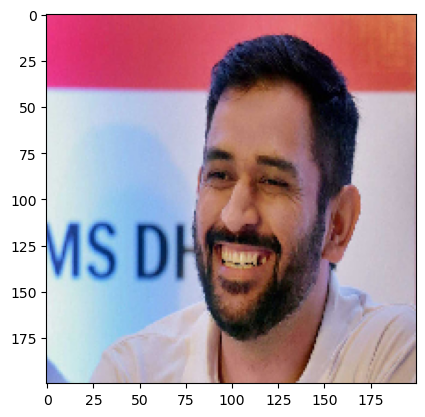

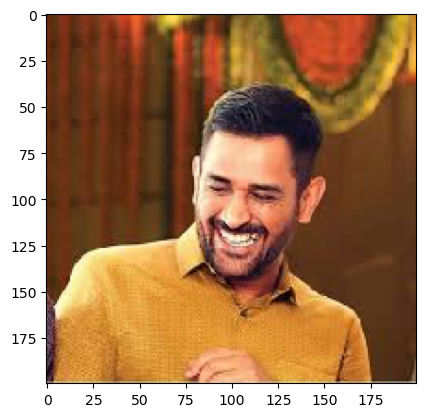

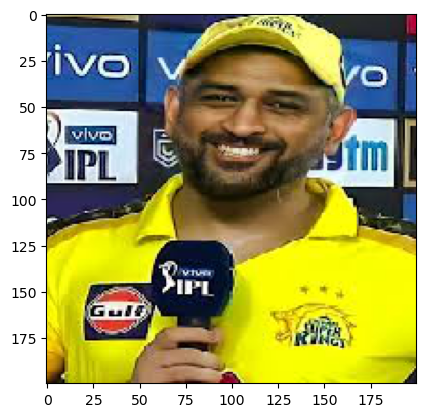

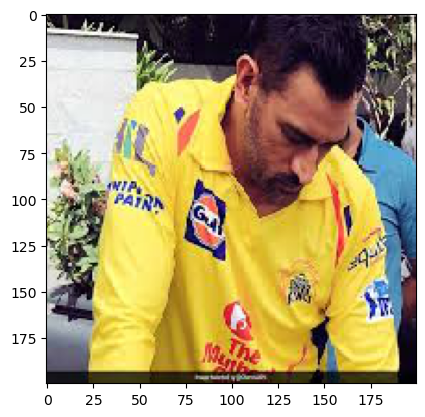

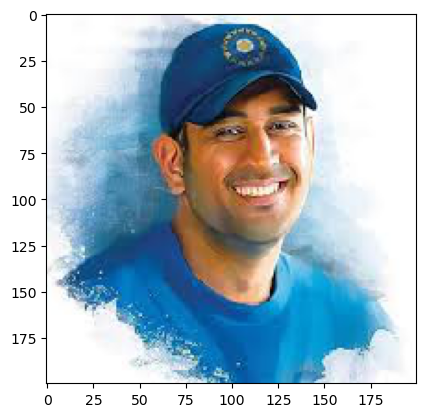

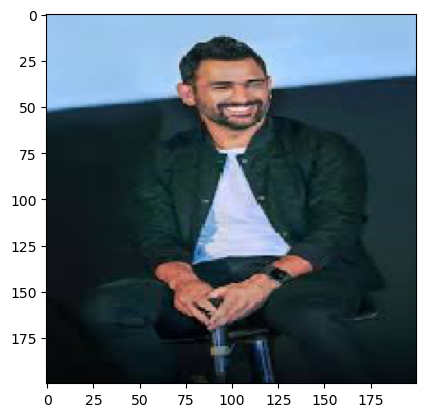

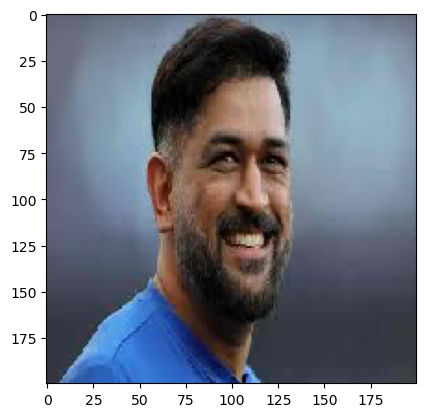

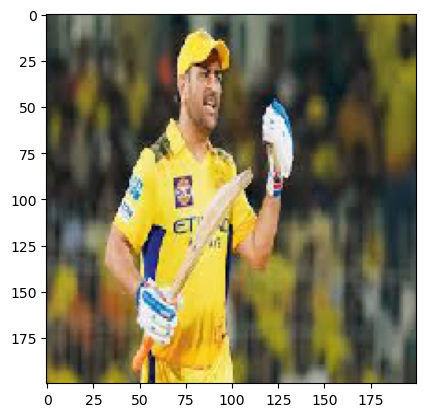

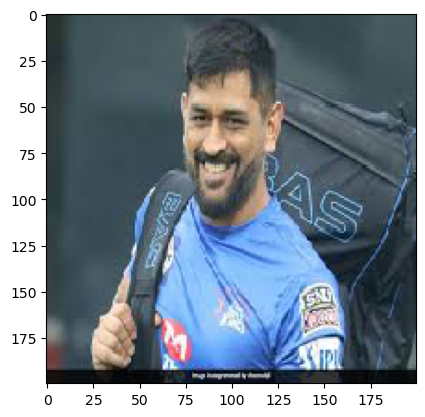

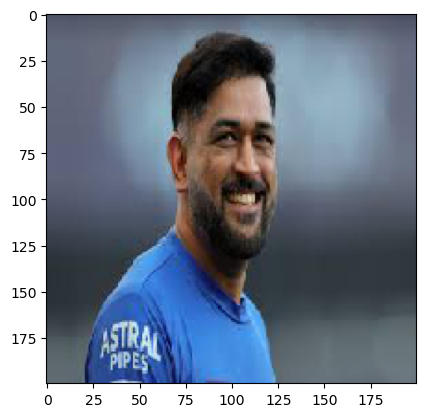

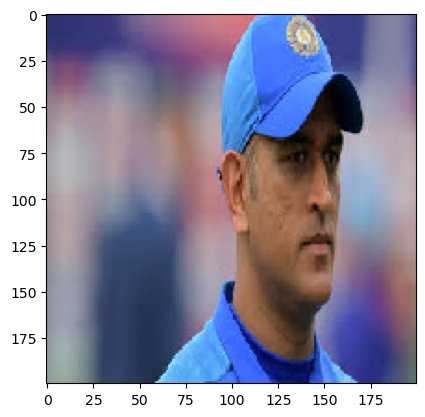

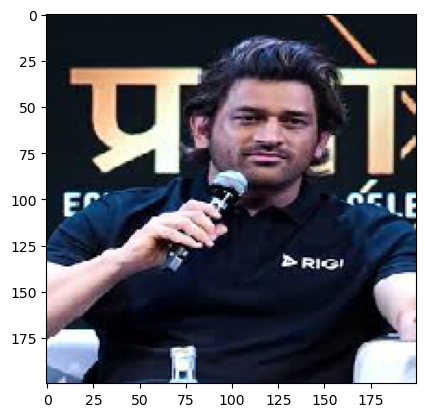

In [ ]:
dir_path=r"C:\Users\aka90\Desktop\abhi vs code\Deep_learning\testing"

for i in os.listdir(dir_path):
    img = image.load_img(dir_path + '//' +i, target_size=(200,200))
    plt.imshow(img)
    plt.show()

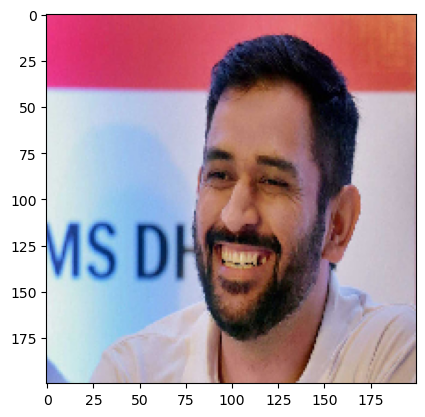

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
I am happy😁


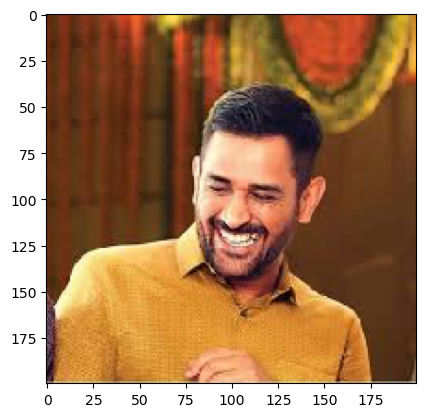

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
I am happy😁


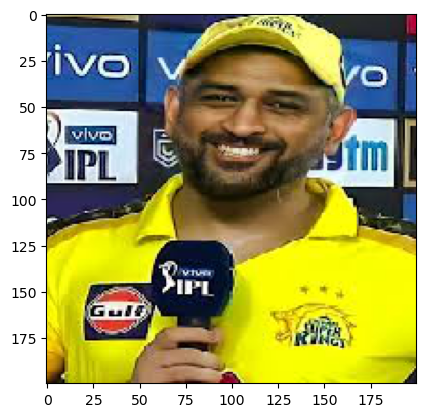

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
I am happy😁


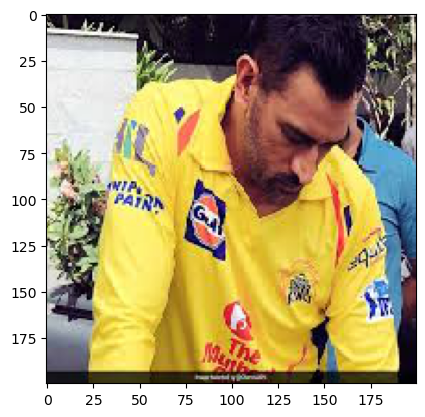

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
I am not happy😢


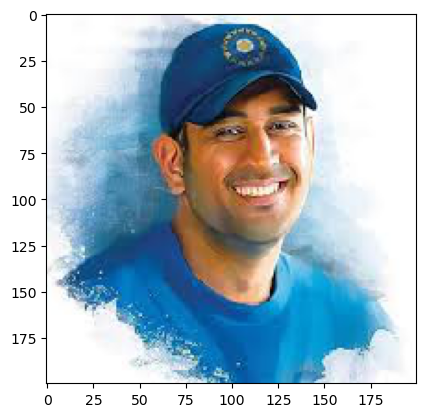

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
I am happy😁


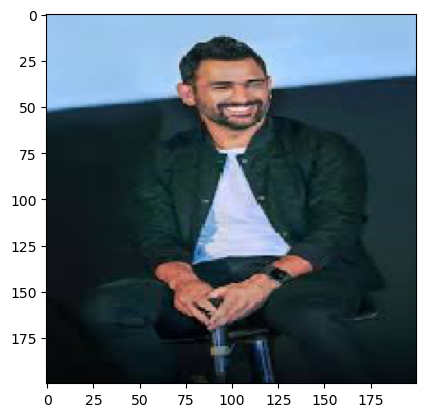

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
I am happy😁


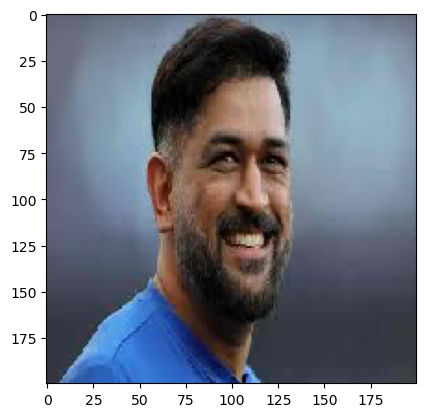

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
I am happy😁


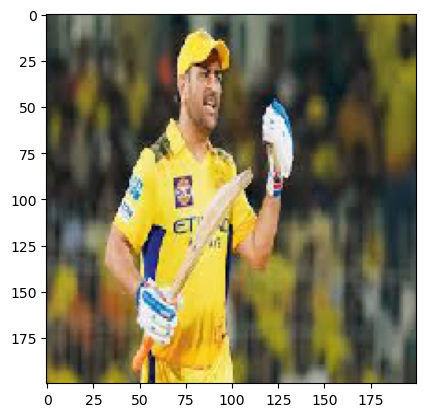

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
I am not happy😢


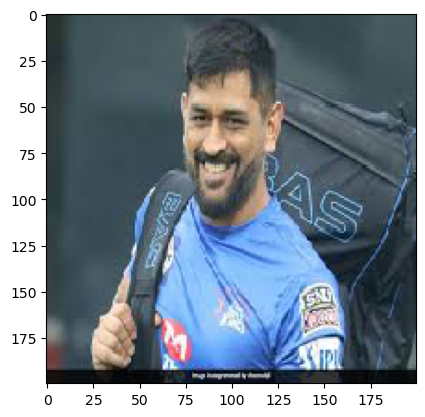

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
I am happy😁


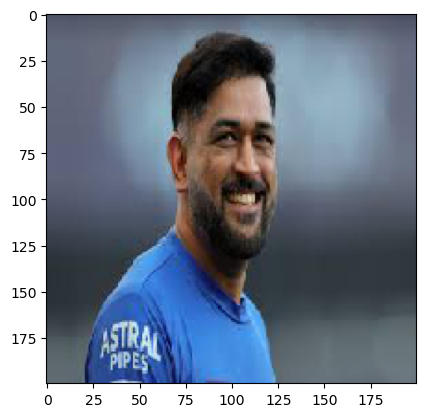

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
I am happy😁


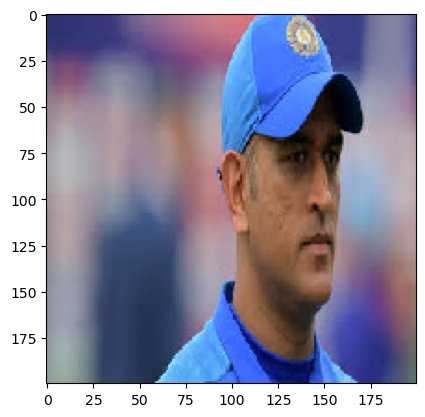

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
I am not happy😢


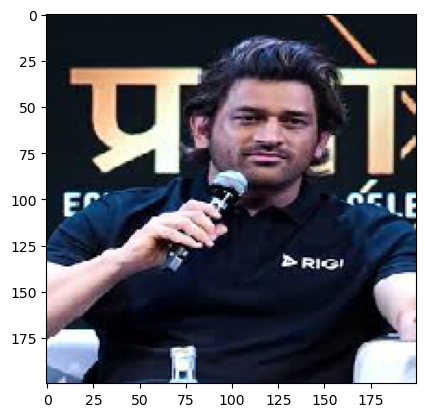

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
I am happy😁


In [38]:
dir_path=r"C:\Users\aka90\Desktop\abhi vs code\Deep_learning\testing"

for i in os.listdir(dir_path):
    img=image.load_img(dir_path + '//' + i, target_size=(200,200))
    plt.imshow(img)
    plt.show()
    
    x=image.img_to_array(img)
    x=np.expand_dims(x,axis=0)
    images=np.vstack([x])
    
    val=model.predict(images)
    if val==0:
        print('I am happy😁')
    else:
        print("I am not happy😢")